# US equities panel: a different question - does momentum cause the return, or predict it?

Every notebook up to here has asked a predictive question: given what is known about a stock
today, what return follows? A model that answers it well has found an association, and an
association is enough to trade on. It is not enough to act on in any other way.

This notebook asks the other question. **Does the treatment change the outcome, or does
something else move both?** The treatment here is `past_ret_12m_skip` - a stock's return over
the past year excluding the most recent month, the standard momentum measure - and the outcome
is the forward return. Momentum predicts returns; that has been true in the panel throughout.
Whether it *causes* them is a different claim, and the difference matters because a predictive
relation can be an artifact of something both variables respond to.

**The something-else is called a confounder**, and this case study declares three: recent
volatility, an illiquidity rank, and a volume ratio. Each plausibly moves both a stock's past
year and its next return, so leaving them alone would let their effect be attributed to
momentum.

**Double machine learning is a way of removing them without assuming the shape of the
relation.** It works in two steps. First, two models predict the outcome from the confounders,
and the treatment from the confounders - these are the **nuisance models**, so called because
nobody is interested in their predictions; they exist to be subtracted. Second, the treatment
effect is estimated from what each model got wrong: the part of the outcome the confounders do
not explain, regressed on the part of the treatment they do not explain. Whatever the confounders
accounted for has been taken out of both sides before the effect is estimated.

**"Double" is why machine learning is safe here.** A flexible model fitted to a confounder makes
its own error, and that error is left behind in whatever the model does not explain. Residualising
*both* sides and estimating the effect from the two residual series cancels that leakage to first
order; residualising one side and regressing on the raw other does not.

**The nuisance models are fitted walk-forward with an embargo**, the same way every predictive
model in this case study is. A confounder model fitted on the whole sample would have removed
something it learned from the future, and the effect estimated afterwards would inherit it.

**Learning objectives.** By the end of this notebook you will be able to:

- State the difference between a predictive and a causal claim about the same pair of variables,
  and say which one a backtest needs.
- Name what a confounder is, and say what happens to an effect estimate if one is left out.
- Describe the two steps of double machine learning and say what each residualisation removes.
- Say why the nuisance models have to be fitted walk-forward, and what a whole-sample fit would
  have leaked.
- State the three assumptions this estimate rests on, and say why a small p-value does not
  establish any of them.
- Explain what a permutation refutation does and does not rule out.

**Book reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence).

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices, and
[`02_labels`](02_labels.ipynb) the outcome label.

**What it writes**: one causal result in `run_log/registry.db`.
[`15_model_analysis`](15_model_analysis.ipynb) reads it in a section of its own. It is never
placed beside a predictive score and never enters a prediction set, because it answers a
different question and is not a ranking.

In [1]:
"""Estimate the configured causal effect through the shared DML boundary."""

import os
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import yaml

from case_studies.research import causal_supersedes, open_study
from utils.modeling import load_configs
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

## What this estimate rests on, and what it cannot establish

Three assumptions carry the causal claim, and none of them is testable from the data:

- **No unmeasured confounder.** Every variable that moves both the treatment and the outcome is
  in the declared list. If one is missing, its effect is still attributed to momentum, and
  nothing in the output says so.
- **Overlap.** At every combination of confounder values that occurs, stocks are found across the
  range of the treatment. Where they are not, the effect at those values is extrapolated rather
  than estimated.
- **No interference.** One stock's treatment does not change another stock's outcome. On a
  cross-sectional strategy operating in one market this is the least comfortable of the three:
  flows into momentum names are exactly the mechanism by which one stock's past return could move
  another's future one.

**Two things are computed that are sometimes mistaken for tests of the above.** The uncertainty
interval is corrected for serial dependence, because overlapping forward returns are not
independent observations and an uncorrected interval would be too narrow. And the **refutation**
permutes the treatment in blocks within each stock and re-estimates, asking how often an effect
this large appears once the treatment's real timing is destroyed. Blocks rather than individual
rows, because permuting row by row would break the serial dependence the test is meant to
preserve, and would return a p-value that reads like a refutation without being one.

**Both check the estimator, not the assumptions.** A small p-value says the effect is unlikely
under the permuted null. It says nothing about whether a confounder was left out, and no
refutation can, because the missing variable is missing from the permutation too.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = ""
CONFIG_NAME = "dml"
NUISANCE_OVERRIDES = {}
EXECUTION_TIER = "canonical"
WORKSPACE = "experiments"
PREVIEW_MAX_SYMBOLS = 0
PREVIEW_MAX_SAMPLES = 0
PREVIEW_N_FOLDS = 0
PREVIEW_N_PLACEBO = 0
SUPERSEDES_CAUSAL: str = ""

## Configure the estimand and execution

The treatment and complete confounder list live in `config/setup.yaml`; the outcome is the label
selected here. `CONFIG_NAME` chooses a published DML configuration. `NUISANCE_OVERRIDES` changes
validated `HistGradientBoostingRegressor` parameters without duplicating the remaining defaults.

Canonical execution uses the complete declared pre-holdout population. A reduced pipeline check
must use `EXECUTION_TIER = 'preview'` and declare at least one reduction. Preview reductions are
part of the immutable identity and cannot enter canonical comparisons or conclusions.

In [3]:
case_dir = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((case_dir / "config" / "setup.yaml").read_text())
label = PRIMARY_LABEL or setup["labels"]["primary"]

published_configs = load_configs(CASE_STUDY_ID, label, family="causal_dml")
published_names = [str(config["config_name"]) for config in published_configs]
if CONFIG_NAME not in published_names:
    raise ValueError(f"Unknown DML configuration: {CONFIG_NAME!r}")

causal_config = setup.get("causal") or {}
treatment = causal_config.get("treatment")
confounders = list(causal_config.get("confounders") or [])
if not treatment:
    raise ValueError("config/setup.yaml must declare causal.treatment")
if not confounders:
    raise ValueError("config/setup.yaml must declare at least one causal.confounder")

config_menu = pl.DataFrame(
    {
        "config_name": published_names,
        "selected": [name == CONFIG_NAME for name in published_names],
        "treatment": [str(treatment)] * len(published_names),
        "outcome": [label] * len(published_names),
    }
)
config_menu

config_name,selected,treatment,outcome
str,bool,str,str
"""dml""",true,"""past_ret_12m_skip""","""fwd_ret_1d"""


In [4]:
preview_reductions = {}
if PREVIEW_MAX_SYMBOLS:
    preview_reductions["max_symbols"] = int(PREVIEW_MAX_SYMBOLS)
if PREVIEW_MAX_SAMPLES:
    preview_reductions["max_samples"] = int(PREVIEW_MAX_SAMPLES)
if PREVIEW_N_FOLDS:
    preview_reductions["n_folds"] = int(PREVIEW_N_FOLDS)
if PREVIEW_N_PLACEBO:
    preview_reductions["n_placebo"] = int(PREVIEW_N_PLACEBO)

# Both tiers resolve the study through `open_study`. It reads the labels and features in place and
# redirects only writes, so a preview run scores the same inputs a canonical one does and cannot
# publish over it.
if EXECUTION_TIER == "canonical":
    if preview_reductions:
        raise ValueError("Canonical execution cannot declare preview reductions")
    study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER)
elif EXECUTION_TIER == "preview":
    if not preview_reductions:
        raise ValueError("Preview execution requires at least one declared reduction")
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(os.environ.get("ML4T_OUTPUT_DIR") or WORKSPACE),
    )
else:
    raise ValueError("EXECUTION_TIER must be 'canonical' or 'preview'")

request = study.causal(
    method="dml",
    label=label,
    config_name=CONFIG_NAME,
    overrides={"nuisance_params": dict(NUISANCE_OVERRIDES)} if NUISANCE_OVERRIDES else {},
    execution_tier=EXECUTION_TIER,
    preview_reductions=preview_reductions,
    supersedes=causal_supersedes(
        study, SUPERSEDES_CAUSAL, label, labels=[label], execution_tier=EXECUTION_TIER
    ),
)
resolved = request.resolve()

## Inspect the resolved request

Resolution fails before fitting if the finalized artifacts omit the treatment or any configured
confounder. The table below is what the run will actually estimate: the treatment and the
confounder list it resolved, the population and temporal design they are estimated over, the
nuisance estimator and the parameters it will be fitted with, and the identity the whole thing
hashes to.

In [5]:
spec = resolved.spec
computation = spec["computation"]
feature_artifacts = computation["feature_artifacts"]
artifact_names = (
    sorted(feature_artifacts)
    if isinstance(feature_artifacts, dict)
    else [str(item) for item in feature_artifacts]
)
resolved_table = pl.DataFrame(
    [
        {
            "config_name": spec["config_name"],
            "label": spec["label"],
            "treatment": computation["estimand"]["treatment"],
            "confounders": computation["estimand"]["confounders"],
            "nuisance_estimator": computation["model"]["class"].rsplit(".", 1)[-1],
            "nuisance_params": computation["model"]["nuisance_params"],
            "feature_artifacts": artifact_names,
            "features": len(computation["feature_names"]),
            "analysis_rows": computation["analysis_population"]["n_rows"],
            "decision_times": computation["analysis_population"]["n_timestamps"],
            "folds": computation["cv"]["n_folds"],
            "placebos": computation["refutation"]["n_placebo"],
            "execution_tier": spec["execution_tier"],
            "causal_hash": resolved.identity,
        }
    ]
)
resolved_table

config_name,label,treatment,confounders,nuisance_estimator,nuisance_params,feature_artifacts,features,analysis_rows,decision_times,folds,placebos,execution_tier,causal_hash
str,str,str,list[str],str,struct[21],list[str],i64,i64,i64,i64,i64,str,str
"""dml""","""fwd_ret_1d""","""past_ret_12m_skip""","[""vol_21d"", ""illiq_rank"", ""volume_ratio""]","""HistGradientBoostingRegressor""","{""from_dtype"",""auto"",null,0.0,0.1,""squared_error"",255,null,1.0,100,31,20,null,10,null,42,""loss"",0.0000001,0.1,0,false}","[""financial"", ""label"", ""model_based""]",71,8387186,6300,5,100,"""canonical""","""8ffe890496bd"""


## Execute and validate the result

A result is registered only once a finite effect and a finite HAC standard error both exist, so
a row in the table below is an estimate rather than an attempt.

Two of its columns are the comparison the method is for. **`naive_effect`** is the slope from
regressing the forward return on momentum with an intercept and nothing removed - the
unadjusted answer, fitted on exactly the rows the second stage uses, so the two estimates are
made on the same sample rather than on samples that differ. **`confounding_bias_pct`** is the
gap between the two, `naive_effect` minus `dml_effect`, as a percentage of the adjusted
estimate's magnitude. It is the size of what the three declared confounders were accounting for,
measured against what remains once they are taken out. A large value says the confounders
mattered; it says
nothing about whether a fourth one is missing.

In [6]:
result = resolved.run()
if not result.complete:
    raise RuntimeError(f"Incomplete causal result: {result.hash}")
if result.hash != resolved.identity:
    raise RuntimeError("Causal result identity differs from the resolved request")
if result.execution_tier != EXECUTION_TIER:
    raise RuntimeError("Causal result execution tier differs from the request")

case_studies/utils/causal.py:1999: UserWarning: block permutation with block_size=252 cannot move 18.20% of the treatment rows: they sit in segments too short to hold two blocks, so the placebo distribution holds them at their observed values and the refutation p-value is biased toward 1. Read placebo_frozen_fraction alongside the p-value, and lower block_size or widen gap_tolerance if the frozen share is large.
  results = run_dml_analysis(


In [7]:
result_table = pl.DataFrame(
    [
        {
            "causal_hash": result.hash,
            "observations": result.metrics["n_obs"],
            "dml_effect": result.metrics["dml_effect"],
            "hac_standard_error": result.metrics["dml_se_hac"],
            "hac_p_value": result.metrics["p_value_hac"],
            "naive_effect": result.metrics["naive_effect"],
            "confounding_bias_pct": result.metrics["confounding_bias_pct"],
            "refutation_p_value": result.metrics["refutation_p"],
            "complete": result.complete,
            "execution_tier": result.execution_tier,
        }
    ]
)
result_table

causal_hash,observations,dml_effect,hac_standard_error,hac_p_value,naive_effect,confounding_bias_pct,refutation_p_value,complete,execution_tier
str,i64,f64,f64,f64,f64,f64,f64,bool,str
"""8ffe890496bd""",7911763,0.000211,0.000309,0.495102,0.000183,-13.339055,1.0,true,"""canonical"""


### What the permuted treatments produced

The refutation p-value above is one number read off the distribution below. Each draw is the
whole estimate redone with the treatment permuted in blocks within each stock, so the draws are
what the estimator produces when the treatment's real timing has been destroyed and everything
else - the confounders, the folds, the nuisance models - is left alone.

**The draws are HAC t-statistics, not effects.** Permuting the treatment frees it from the
controls, so the first stage can no longer predict it and its residual keeps nearly all its
variance - and that variance is the denominator of the second-stage effect. On the effect scale
every placebo is divided by a larger number than the observed estimate, so the placebo
distribution comes out narrower than the null it stands for and always in the direction that
makes a refutation read as passed. Dividing each draw by its own standard error cancels that.

What to read: where the observed t-statistic sits relative to the bulk of the draws. Far out in
a tail means a statistic this size is not something the construction produces by itself. Inside
the bulk means it is. Do not read the spread as precision: t-scale draws come out near unit
spread whatever the sample size, which is the calibration a permutation test should have and is
not a statement about how well this estimand is pinned down.

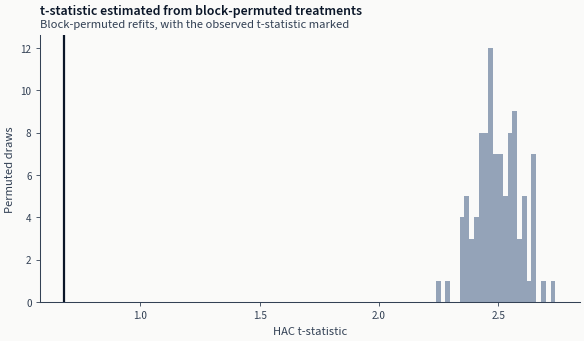

In [8]:
# The draws are read on the t-statistic, which is the scale the p-value above is computed
# on. On the effect scale the permutation distribution is not the null it looks like: a
# permuted treatment is no longer predictable from the confounders, so its residual keeps
# its variance, the second stage divides by a larger number, and every placebo effect is
# pulled toward zero whether or not there is anything to find. Each draw dividing by its
# own standard error is what removes that, and it is why the count below can be compared
# with the p-value beside it.
placebo_t_stats = [float(value) for value in result.metrics.get("placebo_t_stats") or []]
if not placebo_t_stats:
    raise RuntimeError(
        "the causal result registered no placebo t-statistics, so the refutation p-value "
        "above has nothing behind it on the scale it was computed on"
    )
observed_t = float(result.metrics["dml_effect"]) / float(result.metrics["dml_se_hac"])

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.hist(placebo_t_stats, bins=25, color=COLORS["recede"], edgecolor="none")
ax.axvline(observed_t, color=COLORS["blue"], lw=1.6)
ax.set_xlabel("HAC t-statistic")
ax.set_ylabel("Permuted draws")
add_message_title(
    ax,
    "t-statistic estimated from block-permuted treatments",
    subtitle="Block-permuted refits, with the observed t-statistic marked",
)
# The alt text counts rather than asserts. Whether the observed estimate is extreme is the whole
# question, so it is read off the draws instead of being described.
_more_extreme = sum(abs(value) >= abs(observed_t) for value in placebo_t_stats)
show_with_alt(
    fig,
    "A histogram of the HAC t-statistic estimated from block-permuted treatments, with a vertical "
    "line at the t-statistic estimated from the real one. Counted from the draws, "
    f"{_more_extreme} of {len(placebo_t_stats)} permutations produced a t-statistic at least as "
    "large in absolute value as the observed one.",
)

## Downstream handoff

[`15_model_analysis`](15_model_analysis.ipynb) opens this result on its own, apart from the
predictive ones, because it answers a different question and cannot be ranked beside a score.

## What to notice

**The estimate is only as good as the confounder list, and the list is a judgement.** Three
variables are declared here because each plausibly moves both a stock's past year and its next
return. A fourth that nobody thought of would have its effect folded into the momentum estimate,
and every diagnostic in this notebook would still pass.

**A causal estimate is not a signal.** It is not a ranking across stocks, it produces no
prediction, and it cannot be backtested. That is why it is registered separately and read on its
own in [`15_model_analysis`](15_model_analysis.ipynb) rather than placed beside the predictive
results.

**The interesting outcome is not necessarily a large effect.** A predictive relation that persists
after conditioning on the confounders and a causal estimate near zero are both informative:
the first says momentum carries something the three confounders do not, the second says the
association may be something they do carry.

**Known limitations.** The three assumptions above are not established by anything computed
here, and the no-interference one is genuinely doubtful in a single market where flows into
momentum names are a plausible channel between stocks. The estimate is made on the development
sample only. And one treatment, one outcome and one confounder set is one specification: nothing
here explores how the estimate moves under a different plausible choice of any of the three.